<a href="https://colab.research.google.com/github/Shehriyarrkhann/AI-LABS/blob/main/LAB_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 01
# Apply BFS and DFS on trees and graphs. You can use simple examples for your practice.


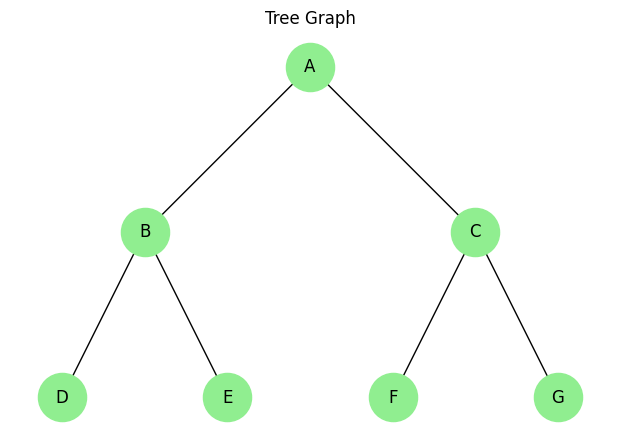

BFS Traversal: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
DFS Traversal: ['A', 'B', 'D', 'E', 'C', 'F', 'G']


In [4]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

# -----------------------------
# 1. Create the tree graph
# -----------------------------
G = nx.Graph()

edges = [
    ('A', 'B'),
    ('A', 'C'),
    ('B', 'D'),
    ('B', 'E'),
    ('C', 'F'),
    ('C', 'G')
]

G.add_edges_from(edges)

# -----------------------------
# 2. Draw tree-like layout
# -----------------------------
pos = {
    'A': (0, 2),
    'B': (-1, 1),
    'C': (1, 1),
    'D': (-1.5, 0),
    'E': (-0.5, 0),
    'F': (0.5, 0),
    'G': (1.5, 0)
}

plt.figure(figsize=(6, 4))
nx.draw(G, pos, with_labels=True,
        node_color='lightgreen',
        node_size=1200,
        font_size=12)
plt.title("Tree Graph")
plt.show()

# -----------------------------
# 3. BFS (Level Order)
# -----------------------------
def bfs(graph, start):
    visited = set()
    queue = deque([start])
    result = []

    while queue:
        node = queue.popleft()

        if node not in visited:
            visited.add(node)
            result.append(node)

            for neighbor in graph.neighbors(node):
                if neighbor not in visited:
                    queue.append(neighbor)

    return result

# -----------------------------
# 4. DFS (Depth First)
# -----------------------------
def dfs(graph, start, visited=None, result=None):
    if visited is None:
        visited = set()
    if result is None:
        result = []

    visited.add(start)
    result.append(start)

    for neighbor in graph.neighbors(start):
        if neighbor not in visited:
            dfs(graph, neighbor, visited, result)

    return result

# -----------------------------
# 5. Run Traversals
# -----------------------------
start_node = 'A'

print("BFS Traversal:", bfs(G, start_node))
print("DFS Traversal:", dfs(G, start_node))


# **Question 02**

In [5]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque


Running for size: 1000
Running for size: 40000
Running for size: 80000
Running for size: 200000
Running for size: 1000000

RESULT TABLE:
      Size  BFS Time (s)  DFS Time (s)
0     1000      0.000156      0.000128
1    40000      0.013897      0.011071
2    80000      0.042327      0.025325
3   200000      0.112745      0.035656
4  1000000      0.907961      0.044910


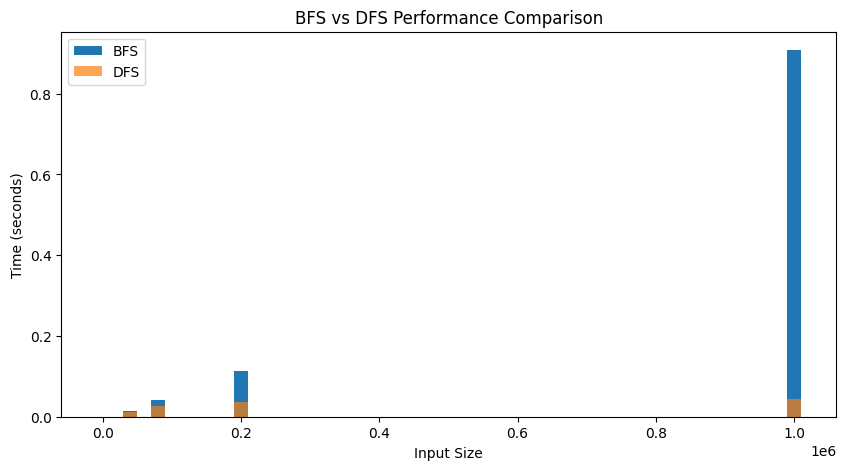

In [6]:
# 1. BFS FUNCTION
# -----------------------------
def bfs(tree, start, goal):
    visited = set()
    queue = deque([start])

    start_time = time.time()

    while queue:
        node = queue.popleft()

        if node == goal:
            return time.time() - start_time

        if node not in visited:
            visited.add(node)
            queue.extend(tree[node])

    return time.time() - start_time


# -----------------------------
# 2. DFS FUNCTION (ITERATIVE)
# -----------------------------
def dfs(tree, start, goal):
    visited = set()
    stack = [start]

    start_time = time.time()

    while stack:
        node = stack.pop()

        if node == goal:
            return time.time() - start_time

        if node not in visited:
            visited.add(node)
            stack.extend(tree[node])

    return time.time() - start_time


# -----------------------------
# 3. BUILD TREE FUNCTION
# -----------------------------
def build_tree(lst):
    tree = {x: [] for x in lst}

    for i in range(len(lst)):
        left = 2*i + 1
        right = 2*i + 2

        if left < len(lst):
            tree[lst[i]].append(lst[left])
        if right < len(lst):
            tree[lst[i]].append(lst[right])

    return tree


# -----------------------------
# 4. DATA SIZES
# -----------------------------
sizes = [1000, 40000, 80000, 200000, 1000000]

results = []

# -----------------------------
# 5. RUN EXPERIMENTS
# -----------------------------
for size in sizes:
    print(f"Running for size: {size}")

    # generate unique random numbers
    data = random.sample(range(size * 10), size)

    tree = build_tree(data)

    goal = data[len(data) - 220]  # required goal

    bfs_time = bfs(tree, data[0], goal)
    dfs_time = dfs(tree, data[0], goal)

    results.append([size, bfs_time, dfs_time])

# -----------------------------
# 6. CREATE DATAFRAME
# -----------------------------
df = pd.DataFrame(results, columns=["Size", "BFS Time (s)", "DFS Time (s)"])

print("\nRESULT TABLE:")
print(df)

# -----------------------------
# 7. PLOT BAR CHART
# -----------------------------
plt.figure(figsize=(10,5))

x = df["Size"]

plt.bar(x, df["BFS Time (s)"], width=20000, label="BFS")
plt.bar(x, df["DFS Time (s)"], width=20000, alpha=0.7, label="DFS")

plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS Performance Comparison")
plt.legend()

plt.show()

# **Question 03**
 Imagine you're a tourist in Pakistan, and you want to travel from Islamabad to Karachi. You want to find the shortest route in terms of the number of cities you need to travel through. The cities are connected through highways, and your goal is to find the shortest path using BFS.**




In [7]:
from collections import deque

# -----------------------------
# 1. Build the graph
# -----------------------------
graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

In [8]:
# 2. BFS for shortest path
# -----------------------------
def bfs_shortest_path(graph, start, goal):
    queue = deque([[start]])   # store paths, not just nodes
    visited = set()

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path  # shortest path found

        if node not in visited:
            visited.add(node)

            for neighbor in graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

    return None

# -----------------------------
# 3. Run BFS
# -----------------------------
start_city = "Islamabad"
goal_city = "Karachi"

shortest_path = bfs_shortest_path(graph, start_city, goal_city)

print("Shortest Path from Islamabad to Karachi:")
print(" → ".join(shortest_path))

print("\nNumber of cities traveled:", len(shortest_path) - 1)

Shortest Path from Islamabad to Karachi:
Islamabad → Rawalpindi → Quetta → Karachi

Number of cities traveled: 3
